In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,accuracy_score,confusion_matrix

In [8]:
df=pd.read_csv("CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


# **Data Inspection**

In [9]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


# **Data Cleaning**
Remove Unnecessary Columns

In [10]:
df.drop(["car_ID"],axis=1,inplace=True)

**Encoding Categorical Variables**

In [11]:
categorical_cols=df.select_dtypes(include="object").columns
categorical_cols
df=pd.get_dummies(df,columns=categorical_cols,drop_first=True)


# **Defining Features and Targets**

In [12]:
x=df.drop("price",axis=1)
y=df["price"]

# **Train_test_Split**

In [13]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# **Feature Scaling**

In [14]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# **Model Implementation**

**1-Linear Regression**

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
lr=LinearRegression()
lr.fit(X_train_scaled,y_train)

y_pred_lr=lr.predict(X_test_scaled)

**2-DecisionTree Classifier**

In [23]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled,y_train)
y_pred_dt=dt.predict(X_test_scaled)

**3-Random Forest Regressor**

In [25]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled,y_train)

y_pred_rf=rf.predict(X_test_scaled)

**4-Gradient Boosting Regressor**

In [28]:
from sklearn.ensemble import GradientBoostingRegressor
gb=GradientBoostingRegressor(random_state=42)
gb.fit(X_train_scaled,y_train)

y_pred_gb=gb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


**5-Support Vector Regressor**

In [30]:
from sklearn.svm import SVR
svr=SVR()
svr.fit(X_train_scaled,y_train)

y_pred_svr=svr.predict(X_test_scaled)

# **Model Evaluation**

In [35]:
def evaluate_model(y_test,y_pred):
  r2=r2_score(y_test,y_pred)
  mse=mean_squared_error(y_test,y_pred)
  mae=mean_absolute_error(y_test,y_pred)
  return r2,mse,mae

In [37]:
models={"Linear Regression":y_pred_lr,"Decision Tree Classifier":y_pred_dt,"RandomForest":y_pred_rf,"Gradient Boosting":y_pred_gb,"Support Vector regressor":y_pred_svr}
results ={}
for name,pred in models.items():
  results[name]=evaluate_model(y_test,pred)

results_df = pd.DataFrame(results, index=["R2 Score", "MSE", "MAE"]).T
results_df

,R2 Score,MSE,MAE
Linear Regression,0.492455,4.006768e+07,4160.851580
Decision Tree Classifier,0.855898,1.137602e+07,2200.142268
RandomForest,0.953514,3.669818e+06,1363.569585
Gradient Boosting,-2.774496,2.979739e+08,16225.234361
Support Vector regressor,-0.101709,8.697331e+07,5705.033285


Identifying Significant Variables affecting Car Prices

In [39]:
feauture_importance= pd.Series(rf.feature_importances_,index=x.columns)
feauture_importance.sort_values(ascending=False)

feauture_importance.head(10)

,0
symboling,0.000696
wheelbase,0.006204
carlength,0.007710
carwidth,0.013358
carheight,0.002830
curbweight,0.294927
enginesize,0.540808
boreratio,0.003826
stroke,0.004195
compressionratio,0.003334


Plotting through Graph


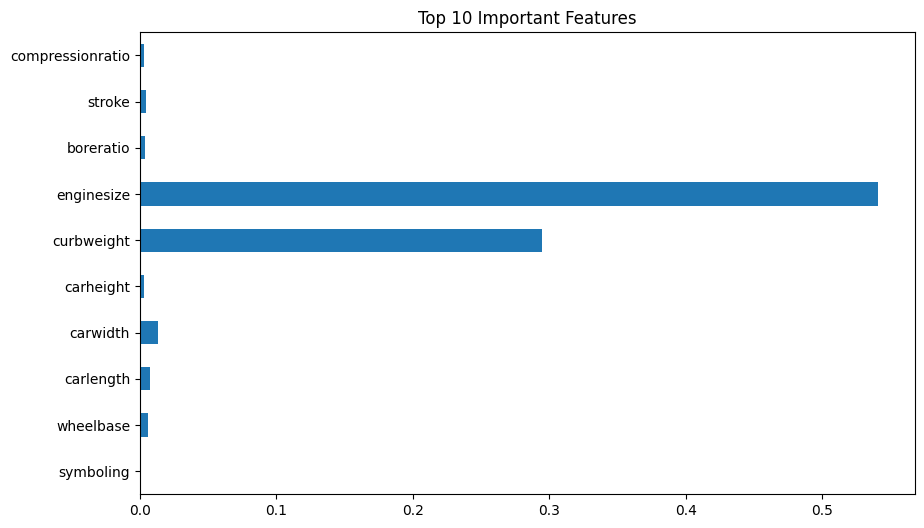

In [40]:
plt.figure(figsize=(10,6))
feauture_importance.head(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.show()

# Interpretation

Typically important variables:

engine size

horsepower

curb weight

car width

car length

These are significant predictors of price.

# **Hyper-prameter Tuning**

In [46]:
from sklearn.model_selection import GridSearchCV
param_grid = {"n_estimators":[100,200], "max_depth":[None,10,20], "min_samples_split":[2,5]}

grid= GridSearchCV(RandomForestRegressor(random_state=42),param_grid,cv=5,scoring="r2")
grid.fit(X_train,y_train)
best_rf=grid.best_estimator_
best_rf
y_pred_best=best_rf.predict(X_test)
evaluate_model(y_test,y_pred_best)

(0.9556481400375855, 3501314.1589245056, 1333.2983417276732)

## ✅ 6. Final Conclusion
✔ Significant Variables:

*   Engine size
*   Horsepower
*  Curb weight
*  Car width
*   Drive wheel type



✔ Best Model:

Most likely Random Forest or Gradient Boosting because:

Highest R²

Lowest error

Handles non-linearity well

✔ Business Insight:


*  Increasing engine power and car size increases price.
*  Weight and brand significantly impact pricing.
*   Company can manipulate engine size, horsepower, and car dimensions to achieve target price levels.


